


# Vamos encher o carrinho!

# Introdução

O Instacart é uma plataforma de entrega de supermercado onde os clientes podem fazer um pedido no supermercado e depois receber sua compra, semelhante ao funcionamento do Uber Eats e do iFood. O conjunto de dados que fornecemos foi modificado a partir do original. Reduzimos o tamanho dele para que seus cálculos sejam executados mais rapidamente e incluímos valores ausentes e duplicados. Também tivemos o cuidado de preservar as distribuições dos dados originais quando fizemos as alterações.

Você precisa completar três etapas. Para cada uma delas, escreva uma breve introdução descrevendo como você pretende concluir a etapa e justifique suas decisões em parágrafos explicativos a medida que você avança na solução. Escreva também uma conclusão para resumir suas conclusões e escolhas.



## Dicionário de dados

Há cinco tabelas no conjunto de dados, e você vai precisar usar todas elas para pré-processar seus dados e fazer AED. Abaixo está um dicionário que lista as colunas de cada tabela e descreve os dados contidos nelas.

- `instacart_orders.csv`: cada linha corresponde a um pedido no aplicativo da Instacart
    - `'order_id'`: é o número que identifica cada pedido de forma exclusiva
    - `'user_id'`: é o número de identificação exclusivo da conta de cada cliente
    - `'order_number'`: é o número de vezes que o cliente fez um pedido
    - `'order_dow'`: é o dia da semana em que o pedido foi feito (0 é domingo)
    - `'order_hour_of_day'`: é a hora do dia em que o pedido foi feito
    - `'days_since_prior_order'`: é o número de dias desde que o cliente fez seu pedido anterior




- `products.csv`: cada linha corresponde a um produto exclusivo que os clientes podem comprar
    - `'product_id'`: é o número de identificação unívoco de cada produto
    - `'product_name'`: é o nome do produto
    - `'aisle_id'`: é o número de identificação exclusivo de cada categoria de corredor do supermercado
    - `'department_id'`: é o número de identificação exclusivo de cada categoria de departamento do supermercado




-	`order_products.csv`: cada linha corresponde a um item incluído em um pedido
    -	`'order_id'`: é o número que identifica cada pedido de forma exclusiva
    -	`'product_id'`: é o número de identificação exclusivo de cada produto
    -	`'add_to_cart_order'`: é a ordem sequencial em que cada item foi colocado no carrinho
    -	`'reordered'`: 0 se o cliente nunca comprou o produto antes, 1 se já o comprou




-	`aisles.csv`
    -	`'aisle_id'`: é o número de identificação exclusivo de cada categoria de corredor do supermercado
    -	`'aisle'`: é o nome do corredor



-	`departments.csv`
    -	`'department_id'`: é o número de identificação exclusivo de cada categoria de departamento do supermercado
    -	`'department'`: é o nome do departamento


# Etapa 1. Visão geral dos dados

Leia os arquivos de dados (/datasets/instacart_orders.csv, /datasets/products.csv, /datasets/aisles.csv, /datasets/departments.csv e /datasets/order_products.csv) com `pd.read_csv()` usando os parâmetros apropriados para fazer isso corretamente. Verifique as informações para cada DataFrame criado.


## Plano de solução

Escreva aqui seu plano para a Etapa 2. Visão geral dos dados

In [1]:
import pandas as pd
import matplotlib.pyplot as plt# Importe as bibliotecas

In [2]:
instacart_orders = pd.read_csv('/datasets/instacart_orders.csv', sep=';')
products = pd.read_csv('/datasets/products.csv', sep=';')
aisles = pd.read_csv('/datasets/aisles.csv', sep=';')
departments = pd.read_csv('/datasets/departments.csv', sep=';')
order_products = pd.read_csv('/datasets/order_products.csv', sep=';')# leia os conjuntos de dados em DataFrames

In [3]:
instacart_orders.info()

# imprima as informações sobre o DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


In [4]:
products.info()
# imprima as informações sobre o DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [5]:
aisles.info()
# imprima as informações sobre o DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


In [6]:
departments.info()
# imprima as informações sobre o DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 464.0+ bytes


In [7]:
order_products.info(show_counts=True)# imprima as informações sobre o DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


## Conclusões

Escreva aqui suas conclusões intermediárias da Etapa 1. Visão geral dos dados

# Etapa 2. Preparação de dados

Faça o pré-processamento dos dados da seguinte maneira:

-	Verifique e corrija os tipos de dados (por exemplo, certifique-se de que as colunas de ID sejam números inteiros)
-	Identifique e preencha valores ausentes
-	Identifique e remova valores duplicados

Certifique-se de explicar que tipos de valores ausentes e duplicados você encontrou, como você os preencheu ou removeu, por que escolheu esses métodos e por que você acha que esses valores ausentes e duplicados estavam presentes no conjunto de dados.

## Plano de solução

Escreva aqui seu plano para a Etapa 2. Preparação de dados

## Encontre e remova valores duplicados (e descreva por que você está fazendo suas escolhas)

### DataFrame `instacart_orders`

In [8]:
instacart_orders['order_id'].duplicated().sum()# Verificar se há pedidos duplicados

15

Há linhas duplicadas? Se sim, o que elas têm em comum?

As linhas duplicadas têm em comum o mesmo identificador de pedido (order_id), o que indica que o mesmo pedido foi registrado mais de uma vez. 

In [9]:
# Com base nas suas conclusões,
orders_2am_wed = instacart_orders[
    (instacart_orders['order_dow'] == 3) &
    (instacart_orders['order_hour_of_day'] == 2)
]

len(orders_2am_wed)
# verifique todos os pedidos feitos às 2h da manhã nas quartas-feiras

121

O que esse resultado quer dizer?

Após aplicar o filtro, o DataFrame retornou 121 linhas, o que significa que 121 pedidos foram feitos nesse dia da semana e nesse horário específico.

In [65]:
instacart_orders = (
    instacart_orders
    .drop_duplicates(subset='order_id')
    .reset_index(drop=True)
)
# Remova pedidos duplicados

In [66]:
instacart_orders.duplicated().sum()

# Verifique as linhas duplicadas mais uma vez

0

In [67]:
instacart_orders['order_id'].duplicated().sum()
# Verifique novamente apenas os IDs de pedidos duplicados

0

Descreva brevemente suas conclusões e o que você fez com elas.

Durante a preparação dos dados, foram identificados pedidos duplicados na tabela de pedidos, o que poderia gerar contagens incorretas nas análises. Esses registros apresentavam o mesmo identificador de pedido (`order_id`), indicando que se tratavam de repetições do mesmo pedido.

Os pedidos duplicados foram removidos mantendo apenas a primeira ocorrência de cada identificador. 


### DataFrame `products`

In [13]:
products.duplicated().sum()
# Verifique se há linhas completamente duplicadas

0

In [14]:
products['product_id'].duplicated().sum()
# Verifique apenas IDs dos produtos duplicados

0

In [15]:
product_names_lower = products['product_name'].str.lower()

product_names_lower.duplicated().sum()
# Verifique apenas nomes de produtos duplicados (converta os nomes para minúsculas para uma comparação melhor)

1361

In [16]:
valid_product_names = products[products['product_name'].notna()]

valid_product_names['product_name'].str.lower().duplicated().sum()
# Verifique os nomes de produtos duplicados que não estão faltando

104

Descreva brevemente suas conclusões e o que você fez com elas.

Na análise do DataFrame `products`, não foram encontradas linhas completamente duplicadas, nem produtos com IDs repetidos. Isso indica que cada produto possui um identificador único.

Ao analisar os nomes dos produtos convertidos para letras minúsculas, foram identificados 1.361 nomes duplicados. Esse número diminui para 104 quando consideramos apenas os registros em que o nome do produto não está ausente. 

Como os IDs dos produtos são únicos nenhuma linha foi removida nesta etapa. Os dados foram mantidos como estão para preservar todas as informações disponíveis apenas alterando os nomes para letra minúscula.


### DataFrame `departments`

In [17]:
departments.duplicated().sum()
# Verifique se há linhas completamente duplicadas

0

In [18]:
departments['department_id'].duplicated().sum()
# Verifique apenas se há IDs dos produtos duplicados

0

Descreva brevemente suas conclusões e o que você fez com elas.

Na tabela `departments`, não foram encontradas linhas completamente duplicadas nem identificadores de departamento repetidos. Isso indica que a tabela está bem estruturada e não foi necessária nenhuma ação de limpeza nesta etapa.


### DataFrame `aisles`

In [19]:
aisles.duplicated().sum()
# Verifique se há linhas completamente duplicadas

0

In [20]:
aisles['aisle_id'].duplicated().sum()
# Verifique apenas se há IDs dos produtos duplicados

0

Descreva brevemente suas conclusões e o que você fez com elas.

Na tabela `aisles`, não foram identificadas linhas duplicadas nem corredores com identificadores repetidos. Os dados estão completos e organizados, não sendo necessária a remoção de registros.


### DataFrame `order_products`

In [21]:
order_products.duplicated().sum()
# Verifique se há linhas completamente duplicadas

0

In [22]:
order_products[['order_id', 'product_id']].duplicated().sum()
# Verifique mais uma vez se há outros casos complicados de duplicados

0

Descreva brevemente suas conclusões e o que você fez com elas.

Na tabela `order_products`, não foram encontradas linhas completamente duplicadas. Também foi verificado se existiam combinações repetidas de `order_id` e `product_id`, e não foram identificadas duplicações nesse nível.

Isso indica que cada produto aparece corretamente associado aos pedidos, e nenhuma remoção de dados foi necessária nessa tabela.


## Encontre e remova valores ausentes


Ao processarmos valores duplicados, observamos que também temos valores ausentes que precisamos investigar nas seguintes colunas:

*	A coluna `'product_name'` da tabela products.
*	A coluna `'days_since_prior_order'` da tabela orders.
*	A coluna `'add_to_cart_order'` da tabela order_products.


### DataFrame `products`

In [23]:
products['product_name'].isna().sum()
# Encontre valores ausentes na coluna 'product_name'

1258

Descreva brevemente suas conclusões.
Foram identificados 1.258 valores ausentes na coluna `product_name`. Isso indica que uma parte dos produtos não possui o nome registrado no conjunto de dados.


In [24]:
products[products['product_name'].isna()]['aisle_id'].value_counts()
# Todos os nomes de produtos ausentes estão associados com o corredor de ID 100?

100    1258
Name: aisle_id, dtype: int64

Descreva brevemente suas conclusões.

Todos os produtos com nome ausente estão associados ao corredor de ID 100. Isso mostra que a ausência de nomes não ocorre de forma aleatória, mas está concentrada em uma categoria específica.


In [25]:
products[products['product_name'].isna()]['department_id'].value_counts()
# Todos os nomes de produtos ausentes estão associados com o departamento de ID 21?

21    1258
Name: department_id, dtype: int64

Descreva brevemente suas conclusões.

Todos os produtos com nome ausente pertencem ao departamento de ID 21. Esse resultado reforça que os valores ausentes estão relacionados a um grupo específico de produtos.


In [26]:
aisles[aisles['aisle_id'] == 100]
departments[departments['department_id'] == 21]

# Use as tabelas department e aisle para verificar os dados do corredor com ID 100 e do departamento com ID 21.

,department_id,department
20,21,missing


Descreva brevemente suas conclusões.
Ao consultar as tabelas de referência, foi possível verificar que o departamento de ID 21 está identificado como "missing". Isso explica por que os produtos associados a esse departamento não possuem nomes registrados no conjunto de dados.


In [27]:
products['product_name'] = products['product_name'].fillna('Unknown')
# Preencha nomes de produtos ausentes com 'Unknown'

Descreva brevemente suas conclusões e o que você fez com elas.

Os nomes de produtos ausentes foram preenchidos com o valor "Unknown". Essa decisão permite manter todos os registros no conjunto de dados sem remover produtos, preservando a integridade das análises futuras e viabilizando uma leitura mais transparente, tendo em vista que "missing" pode gerar interpretações mais subjetivas sobre o produto e "unknown" gera uma interpretação mais objetiva e clara.


### DataFrame `orders`

In [28]:
instacart_orders['days_since_prior_order'].isna().sum()
# Encontre os valores ausentes

28817

In [29]:
instacart_orders[
    (instacart_orders['days_since_prior_order'].isna()) &
    (instacart_orders['order_number'] > 1)
].shape[0]
# Há valores ausentes para os clientes que não estão fazendo o primeiro pedido?

0

Descreva brevemente suas conclusões e o que você fez com elas.

Foram identificados 28.817 valores ausentes na coluna `days_since_prior_order`. Ao verificar esses casos, constatou-se que todos os valores ausentes estão associados a clientes que estão realizando o primeiro pedido, ou seja, possuem `order_number` igual a 1.

Não foram encontrados valores ausentes para clientes que já haviam feito pedidos anteriormente. Isso indica que a ausência dessa informação é esperada, pois não existe um pedido anterior para calcular o intervalo de dias.

Dessa forma, os valores ausentes foram mantidos, pois representam uma situação válida e não indicam erro nos dados.


### DataFrame `order_products`

In [30]:
order_products['add_to_cart_order'].isna().sum()
# Encontre os valores ausentes

836

In [31]:
order_products['add_to_cart_order'].min(), order_products['add_to_cart_order'].max()
# Quais são os valores mínimo e máximo dessa coluna?

(1.0, 64.0)

Descreva brevemente suas conclusões.

Foram identificados 836 valores ausentes na coluna `add_to_cart_order`. Os valores dessa coluna variam de 1 a 64.

In [32]:
orders_with_missing_cart = order_products[
    order_products['add_to_cart_order'].isna()
]['order_id'].unique()
# Salve todos os IDs dos pedidos com pelo menos um valor ausente em 'add_to_cart_order'

In [33]:
# Todos os pedidos com valores ausentes contêm mais de 64 produtos?
# Agrupe os pedidos com dados ausentes por ID de pedido
# Conte o número de 'product_id' em cada pedido e verifique o valor mínimo da contagem

products_per_order = (
    order_products[order_products['order_id'].isin(orders_with_missing_cart)]
    .groupby('order_id')['product_id']
    .count()
)

products_per_order.min()

65

Descreva brevemente suas conclusões.

Ao analisar os pedidos que possuem pelo menos um valor ausente nessa coluna, verificou-se que todos esses pedidos contêm mais de 64 produtos. O menor número de produtos observado nesses pedidos foi 65.
Isso indica que os valores ausentes estão associados a pedidos muito grandes.


In [34]:
order_products['add_to_cart_order'] = (
    order_products['add_to_cart_order']
    .fillna(999)
    .astype(int)
)
# Substitua valores ausentes na coluna 'add_to_cart_order' por 999 e converta a coluna para o tipo integer

Descreva brevemente suas conclusões e o que você fez com elas.

Os valores ausentes da coluna `add_to_cart_order` foram substituídos por 999, um valor que indica que a posição do produto no carrinho não foi registrada. Em seguida, a coluna foi convertida para o tipo inteiro buscando viabilizar uma analise mais consistente.


## Conclusões

Escreva aqui suas conclusões intermediárias da Etapa 2. Preparação de dados

Nesta etapa, realizamos a preparação dos dados com o objetivo de garantir que o conjunto estivesse consistente e adequado para a análise exploratória.

Identifiquei registros duplicados na tabela de pedidos que foram removidos para evitar contagens incorretas. Nas demais tabelas, não foram encontradas duplicações de dados.

Também foram analisados os valores ausentes em diferentes colunas. Na tabela de produtos, os nomes ausentes estavam concentrados em uma categoria específica identificada como “missing”, e por isso foram preenchidos com o valor "Unknown" para gerar mais transparência nos dados. Já na tabela de pedidos, os valores ausentes relacionados ao tempo desde o pedido anterior correspondem apenas aos primeiros pedidos dos clientes, representando uma situação esperada e, portanto, foram mantidos.

Na tabela de itens por pedido, os valores ausentes na coluna que indica a ordem de inclusão no carrinho estão associados a pedidos muito grandes, com mais de 64 produtos. Esses valores foram substituídos por 999 para indicar explicitamente a ausência dessa informação, e a coluna foi convertida para o tipo inteiro.

# Etapa 3. Análise de dados

Quando os dados estiverem processados ​​e prontos, execute a seguinte análise:

# [A] Fácil (é necessário concluir tudo para passar)

1.	Verifique se os valores nas colunas `'order_hour_of_day'` e `'order_dow'` na tabela `orders` fazem sentido (ou seja, os valores da coluna  `'order_hour_of_day'` variam de 0 a 23 e os da `'order_dow'` variam de 0 a 6).
2.	Crie um gráfico que mostre quantas pessoas fazem pedidos a cada hora do dia.
3.	Crie um gráfico que mostre em que dia da semana as pessoas fazem compras.
4.	Crie um gráfico que mostre quanto tempo as pessoas esperam até fazer seu próximo pedido e comente sobre os valores mínimo e máximo.


### [A1] Verifique se os valores fazem sentido

In [35]:
instacart_orders['order_hour_of_day'].min(), instacart_orders['order_hour_of_day'].max()


(0, 23)

In [36]:
instacart_orders['order_dow'].min(), instacart_orders['order_dow'].max()


(0, 6)

Escreva suas conclusões aqui

Os valores da coluna `order_hour_of_day` variam de 0 a 23, o que corresponde corretamente às horas do dia. Da mesma forma, os valores da coluna `order_dow` variam de 0 a 6, representando os dias da semana, onde 0 corresponde ao domingo.

Isso indica que os dados dessas colunas estão dentro dos intervalos esperados e fazem sentido para a análise.


### [A2] Quantas pessoas fazem pedidos a cada hora do dia?

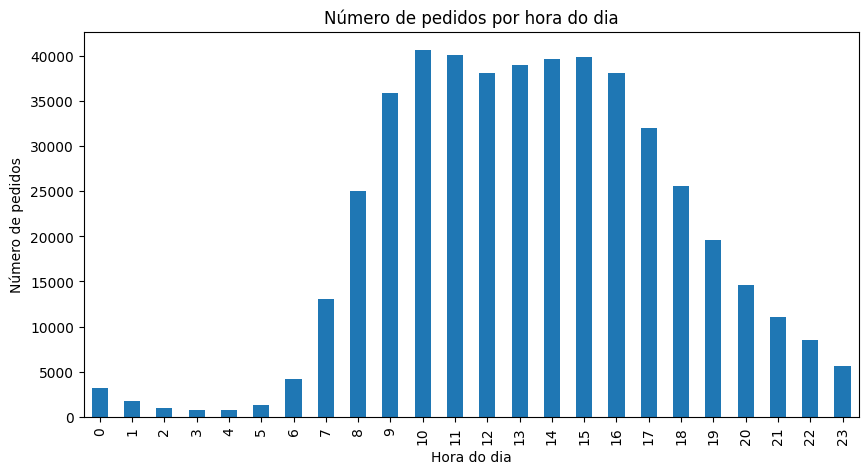

In [37]:
import matplotlib.pyplot as plt

orders_by_hour = instacart_orders['order_hour_of_day'].value_counts().sort_index()

orders_by_hour.plot(kind='bar', figsize=(10, 5))
plt.title('Número de pedidos por hora do dia')
plt.xlabel('Hora do dia')
plt.ylabel('Número de pedidos')
plt.show()


Escreva suas conclusões aqui

O gráfico mostra que a maior parte dos pedidos é realizada durante o dia, principalmente entre o final da manhã e o início da noite. Durante a madrugada, o número de pedidos é consideravelmente menor, indicando menor atividade nesse período.



### [A3] Em que dia da semana as pessoas compram produtos alimentícios?

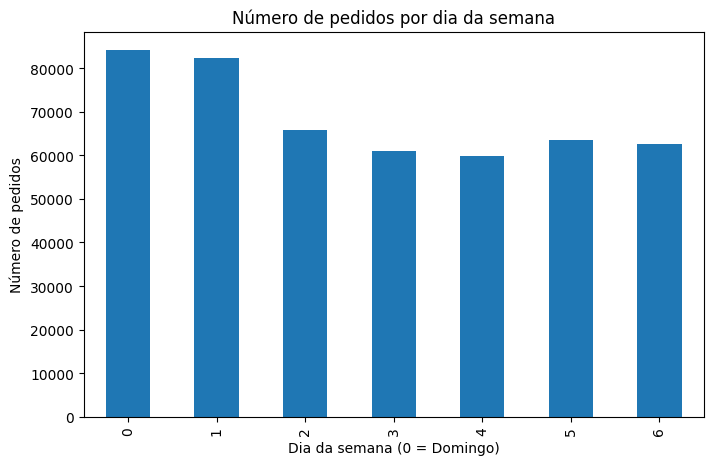

In [38]:
orders_by_day = instacart_orders['order_dow'].value_counts().sort_index()

orders_by_day.plot(kind='bar', figsize=(8, 5))
plt.title('Número de pedidos por dia da semana')
plt.xlabel('Dia da semana (0 = Domingo)')
plt.ylabel('Número de pedidos')
plt.show()


Escreva suas conclusões aqui

Observa-se que o volume de pedidos varia ao longo da semana, com maior concentração no início da semana. 


### [A4] Quanto tempo as pessoas esperam até fazer outro pedido?

Escreva suas conclusões aqui

O gráfico mostra que a maioria dos clientes realiza um novo pedido poucos dias após o pedido anterior, com maior concentração entre aproximadamente 3 e 10 dias. Isso indica um comportamento de compra frequente e relativamente regular.

Também é possível observar um pico significativo no valor máximo de 30 dias. Esse comportamento sugere que muitos clientes tendem a fazer pedidos em ciclos mensais, o que pode estar relacionado a hábitos de planejamento de compras.

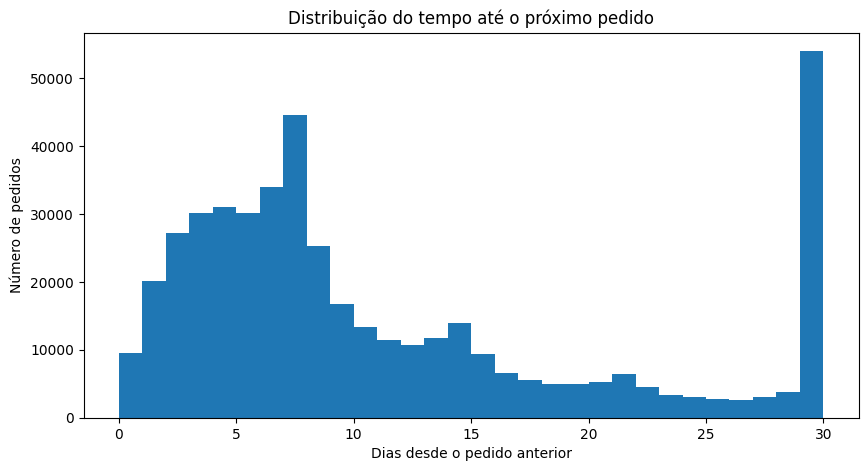

(0.0, 30.0)

In [39]:
instacart_orders['days_since_prior_order'].plot(
    kind='hist',
    bins=30,
    figsize=(10, 5)
)

plt.title('Distribuição do tempo até o próximo pedido')
plt.xlabel('Dias desde o pedido anterior')
plt.ylabel('Número de pedidos')
plt.show()

instacart_orders['days_since_prior_order'].min(), instacart_orders['days_since_prior_order'].max()


# [B] Médio (é necessário concluir tudo para passar)

1.	Há alguma diferença nas distribuições de `'order_hour_of_day'` nas quartas e sábados? Construa gráficos de barras para ambos os dias no mesmo gráfico e descreva as diferenças que você notou.
2.	Construa um gráfico de distribuição para o número de pedidos que os clientes fazem (ou seja, quantos clientes fizeram apenas 1 pedido, quantos fizeram apenas 2, quantos apenas 3, etc.)
3.	Quais são os 20 produtos comprados com mais frequência? Exiba os IDs e nomes.


### [B1] Diferenças nas quartas e sábados em `'order_hour_of_day'`. Crie gráficos de barras para ambos os dias e descreva as diferenças.

In [69]:
import matplotlib.pyplot as plt
import numpy as np

In [70]:
wed = instacart_orders[instacart_orders['order_dow'] == 3]['order_hour_of_day']
sat = instacart_orders[instacart_orders['order_dow'] == 6]['order_hour_of_day']

In [72]:
wed_counts = wed.value_counts().sort_index()
sat_counts = sat.value_counts().sort_index()

hours = np.arange(0, 24)
wed_counts = wed_counts.reindex(hours, fill_value=0)
sat_counts = sat_counts.reindex(hours, fill_value=0)

width = 0.4

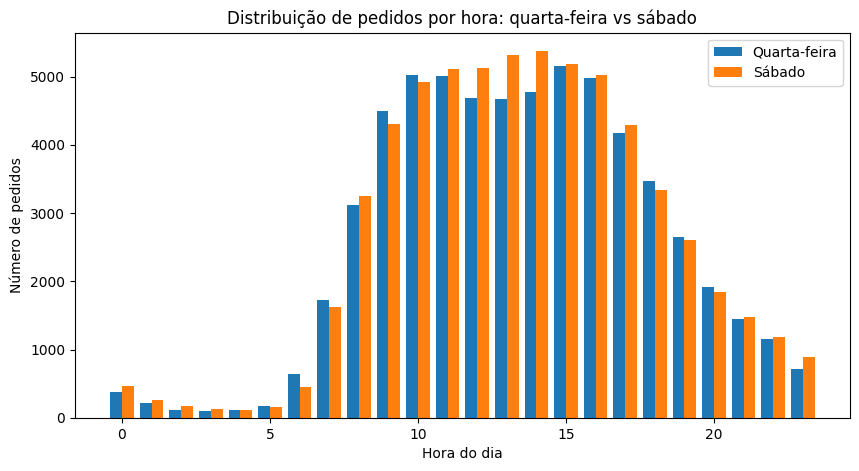

In [73]:
plt.figure(figsize=(10, 5))
plt.bar(hours - width/2, wed_counts.values, width=width, label='Quarta-feira')
plt.bar(hours + width/2, sat_counts.values, width=width, label='Sábado')

plt.title('Distribuição de pedidos por hora: quarta-feira vs sábado')
plt.xlabel('Hora do dia')
plt.ylabel('Número de pedidos')
plt.legend()
plt.show()

Escreva suas conclusões aqui

O gráfico evidencia diferenças claras no comportamento de pedidos entre a quarta-feira e o sábado. 

Na quarta-feira, os pedidos se concentram principalmente entre o final da manhã e final da tarde, refletindo um padrão mais alinhado à rotina semanal dos clientes.

No sábado, os pedidos são mais distribuídos ao longo do dia, com maior volume durante a manhã e a tarde. Em vários horários, especialmente entre 10h e 15h, o número de pedidos aos sábados supera o observado nas quartas-feiras.

Esses resultados indicam que, enquanto a quarta-feira apresenta um comportamento mais concentrado em horários específicos, o sábado reflete maior flexibilidade, com clientes realizando pedidos ao longo de um período mais amplo do dia.


### [B2] Qual é a distribuição do número de pedidos por cliente?

In [44]:
orders_per_user = instacart_orders.groupby('user_id')['order_id'].count()

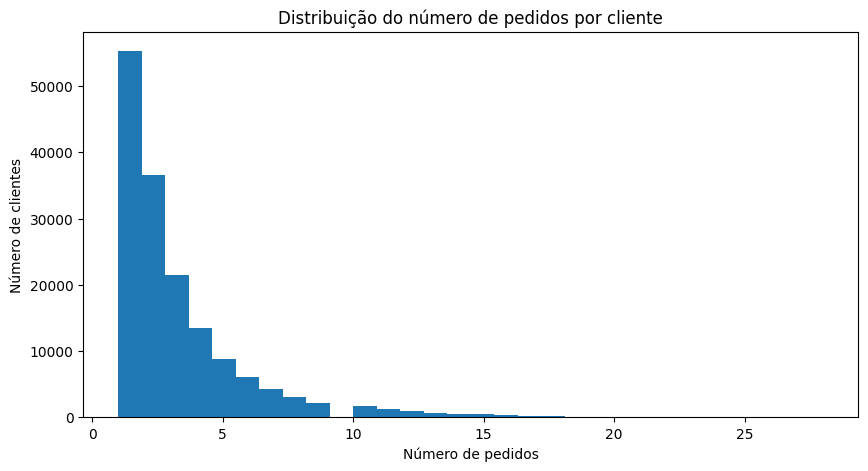

In [45]:
orders_per_user.plot(kind='hist', bins=30, figsize=(10, 5))

plt.title('Distribuição do número de pedidos por cliente')
plt.xlabel('Número de pedidos')
plt.ylabel('Número de clientes')
plt.show()



Escreva suas conclusões aqui

O gráfico mostra que a maioria dos clientes realizou apenas um ou poucos pedidos na plataforma. Há um grande volume de clientes com até dois ou três pedidos, e a quantidade de clientes diminui rapidamente à medida que o número de pedidos aumenta.

Também é possível observar uma cauda longa na distribuição, indicando que existe um grupo menor de clientes que realiza muitos pedidos. Esses clientes representam os usuários mais frequentes e engajados da plataforma.

De forma geral, a distribuição indica que a base de clientes é composta majoritariamente por usuários ocasionais, com uma parcela menor de clientes recorrentes.


### [B3] Quais são os 20 produtos mais populares? Exiba os IDs e nomes.

In [46]:
top_20_products = (
    order_products['product_id']
    .value_counts()
    .head(20)
    .reset_index()
)




In [47]:
top_20_products.columns = ['product_id', 'number_of_purchases']

In [48]:
top_20_products = top_20_products.merge(
    products[['product_id', 'product_name']],
    on='product_id',
    how='left'
)

top_20_products


,product_id,number_of_purchases,product_name
0,24852,66050,Banana
1,13176,53297,Bag of Organic Bananas
2,21137,37039,Organic Strawberries
3,21903,33971,Organic Baby Spinach
4,47209,29773,Organic Hass Avocado
5,47766,24689,Organic Avocado
6,47626,21495,Large Lemon
7,16797,20018,Strawberries
8,26209,19690,Limes
9,27845,19600,Organic Whole Milk


Escreva suas conclusões aqui

A tabela dos 20 produtos mais populares mostra que os itens mais comprados pelos clientes da Instacart são, em sua maioria, itens orgânicos e itens básicos do dia a dia.

O produto mais comprado é a banana, seguida por diferentes variações de produtos orgânicos, o que indica uma forte preferência dos clientes por alimentos frescos e saudáveis. Esses são, em sua maioria, produtos com tempo de validade viabilizando, de certa forma, o retorno dos clientes para a realização de próximos pedidos.

# [C] Difícil (é necessário concluir pelo menos duas perguntas para passar)

1.	Quantos itens as pessoas normalmente compram em um pedido? Como fica a distribuição?
2.	Quais são os 20 principais itens incluídos mais frequentemente em pedidos repetidos? Exiba os IDs e nomes.
3.	Para cada produto, qual parcela de seus pedidos são repetidos? Crie uma tabela com colunas de ID e nome do produto e a proporção de pedidos repetidos.
4.	Para cada cliente, qual proporção de todos os seus pedidos são repetidos?
5.	Quais são os 20 principais itens que as pessoas colocam nos carrinhos antes de todos os outros? Exiba o ID do produto, nome e o número de vezes que ele foi o primeiro a ser adicionado a um carrinho.


### [C1] Quantos itens as pessoas normalmente compram em um pedido? Como fica a distribuição?

In [49]:
items_per_order = (
    order_products
    .groupby('order_id')['product_id']
    .count()
)


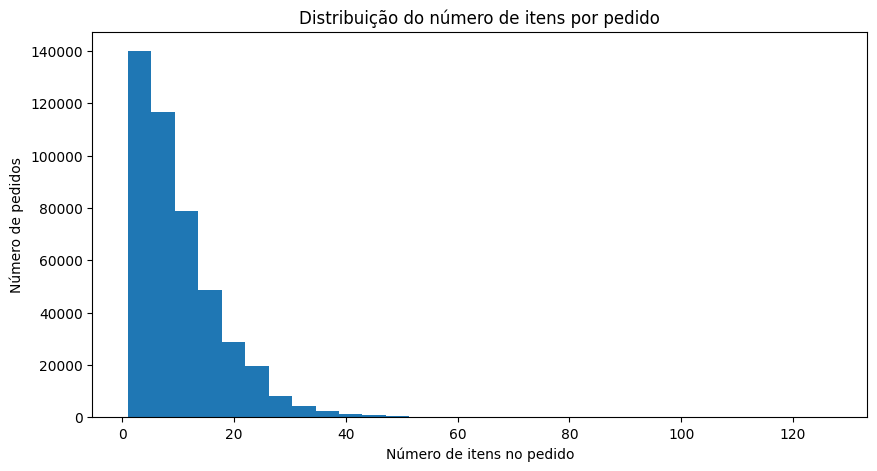

In [50]:
import matplotlib.pyplot as plt

items_per_order.plot(kind='hist', bins=30, figsize=(10, 5))

plt.title('Distribuição do número de itens por pedido')
plt.xlabel('Número de itens no pedido')
plt.ylabel('Número de pedidos')
plt.show()


In [51]:
items_per_order.min(), items_per_order.max()


(1, 127)

Escreva suas conclusões aqui

O gráfico mostra que a maioria dos pedidos contém poucos itens, com maior concentração entre aproximadamente 1 e pouco menos que 20 produtos por pedido. Isso indica que os clientes geralmente realizam compras menores e mais frequentes.

À medida que o número de itens aumenta, a quantidade de pedidos diminui rapidamente, formando uma cauda longa na distribuição. O valor mínimo observado foi de 1 item por pedido, enquanto o valor máximo chegou a 127 itens, indicando que, embora raros, existem pedidos muito grandes.


De forma geral, os resultados mostram que o comportamento predominante dos clientes é realizar pedidos com poucos itens, enquanto pedidos com muitos produtos representam exceções.



### [C2] Quais são os 20 principais itens incluídos com mais frequência em pedidos repetidos? Exiba os IDs e nomes.

In [52]:
reordered_products = order_products[order_products['reordered'] == 1]


In [53]:
top_20_reordered = (
    reordered_products['product_id']
    .value_counts()
    .head(20)
    .reset_index()
)




In [54]:
top_20_reordered.columns = ['product_id', 'number_of_reorders']


In [55]:
top_20_reordered = top_20_reordered.merge(
    products[['product_id', 'product_name']],
    on='product_id',
    how='left'
)

top_20_reordered


,product_id,number_of_reorders,product_name
0,24852,55763,Banana
1,13176,44450,Bag of Organic Bananas
2,21137,28639,Organic Strawberries
3,21903,26233,Organic Baby Spinach
4,47209,23629,Organic Hass Avocado
5,47766,18743,Organic Avocado
6,27845,16251,Organic Whole Milk
7,47626,15044,Large Lemon
8,27966,14748,Organic Raspberries
9,16797,13945,Strawberries


Escreva suas conclusões aqui

A lista dos 20 itens mais frequentes em pedidos repetidos mostra que os produtos que os clientes mais recompõem em suas compras são, em sua maioria, alimentos básicos e de consumo recorrente, como frutas, vegetais e outros itens essenciais.

Esse resultado indica que os clientes tendem a repetir a compra dos mesmos produtos ao longo do tempo, especialmente aqueles utilizados no dia a dia. Isso reforça a ideia de fidelidade a determinados itens e padrões consistentes de consumo.


### [C3] Para cada produto, qual parcela de todos os pedidos dele são repetidos?

In [56]:
total_orders_per_product = (
    order_products
    .groupby('product_id')['order_id']
    .count()
)


In [57]:
reordered_per_product = (
    order_products
    .groupby('product_id')['reordered']
    .sum()
)
reorder_ratio = reordered_per_product / total_orders_per_product


In [58]:
reorder_ratio_df = (
    reorder_ratio
    .reset_index()
    .rename(columns={0: 'reorder_ratio'})
)

reorder_ratio_df = reorder_ratio_df.merge(
    products[['product_id', 'product_name']],
    on='product_id',
    how='left'
)

reorder_ratio_df.head()


,product_id,reorder_ratio,product_name
0,1,0.564286,Chocolate Sandwich Cookies
1,2,0.000000,All-Seasons Salt
2,3,0.738095,Robust Golden Unsweetened Oolong Tea
3,4,0.510204,Smart Ones Classic Favorites Mini Rigatoni Wit...
4,7,0.500000,Pure Coconut Water With Orange


Escreva suas conclusões aqui

A tabela mostra que a proporção de pedidos repetidos varia significativamente entre os produtos. Alguns itens apresentam uma alta taxa de recompra, indicando que os clientes tendem a adquiri-los novamente em pedidos futuros.

Por exemplo, produtos como "Chocolate Sandwich Cookies" e "Robust Golden Unsweetened Oolong Tea" possuem mais da metade de seus pedidos classificados como repetidos, o que sugere forte recorrência e fidelidade dos clientes a esses itens.

Por outro lado, há produtos com proporção de pedidos repetidos muito baixa ou nula, como *All-Seasons Salt*, indicando que esses itens são comprados de forma mais pontual ou ocasional.

Essas diferenças mostram que alguns produtos fazem parte da rotina de compras dos clientes, enquanto outros têm um papel mais esporádico, ajudando a entender padrões de consumo e fidelização.

### [C4] Para cada cliente, qual proporção de todos os seus pedidos são repetidos?

In [59]:
orders_users = instacart_orders[['order_id', 'user_id']]
order_products_users = order_products.merge(
    orders_users, on='order_id', how='left'
)


In [60]:
reorder_ratio_by_user = (
    order_products_users
    .groupby('user_id')['reordered']
    .mean()
    .reset_index(name='reorder_ratio')
)

reorder_ratio_by_user.head()


,user_id,reorder_ratio
0,2,0.038462
1,4,0.000000
2,5,0.666667
3,6,0.000000
4,7,0.928571


Escreva suas conclusões aqui

Os resultados mostram que a proporção de pedidos repetidos varia significativamente entre os clientes. Alguns clientes apresentam proporções muito altas de pedidos repetidos, próximas de 1, indicando que a maior parte dos itens comprados por esses clientes já havia sido adquirida anteriormente.

Há clientes com proporção igual a 0, o que indica que eles não realizaram pedidos repetidos no período analisado.

Também há casos intermediários, com proporções moderadas de pedidos repetidos. Esses resultados evidenciam a diversidade de perfis de clientes na plataforma.


### [C5] Quais são os 20 principais itens que as pessoas colocam nos carrinhos antes de todos os outros?

In [61]:
first_items = order_products[order_products['add_to_cart_order'] == 1]


In [62]:
top_20_first_items = (
    first_items['product_id']
    .value_counts()
    .head(20)
    .reset_index()
)

top_20_first_items.columns = ['product_id', 'times_first_added']


In [63]:
top_20_first_items = top_20_first_items.merge(
    products[['product_id', 'product_name']],
    on='product_id',
    how='left'
)

top_20_first_items


,product_id,times_first_added,product_name
0,24852,15562,Banana
1,13176,11026,Bag of Organic Bananas
2,27845,4363,Organic Whole Milk
3,21137,3946,Organic Strawberries
4,47209,3390,Organic Hass Avocado
5,21903,3336,Organic Baby Spinach
6,47766,3044,Organic Avocado
7,19660,2336,Spring Water
8,16797,2308,Strawberries
9,27966,2024,Organic Raspberries


Escreva suas conclusões aqui

A banana aparece como o item mais comum nessa posição, seguida por variações de produtos orgânicos, como bananas orgânicas, leite orgânico, morangos e abacates.

Esse padrão sugere que os clientes tendem a iniciar suas compras com produtos essenciais, utilizando-os como ponto de partida para montar o restante do pedido. Além disso, a forte presença de itens orgânicos entre os primeiros adicionados indica uma preferência consistente por esse tipo de produto.

Esses resultados ajudam a compreender a lógica de navegação dos clientes e indicam quais produtos têm maior destaque no início do processo de compra, expondo o comportamento do consumidor frente as opções de produtos ofertados. 


# Conclusão geral do projeto:

In [64]:
# Trabalhamos com um conjunto de dados da Instacart com o objetivo de compreender os hábitos de compra dos clientes e garantir que os dados utilizados estivessem adequados para análise.

# Na Etapa 1, realizamos a leitura dos conjuntos de dados e uma inspeção inicial de suas estruturas. O que permitiu entender o papel de cada tabela, os tipos de dados presentes e identificar a existência de valores ausentes e possíveis duplicações.
#Na Etapa 2, limpamos e organizamos os dados, identificamos e removemos registros duplicados na tabela de pedidos, evitando contagens incorretas, analisamos valores ausentes em diferentes colunas, investigando sua origem antes de tomar qualquer decisão,alguns valores ausentes representavam situações esperadas, como o primeiro pedido de um cliente, enquanto outros estavam concentrados em categorias específicas. 

#Preenchemos os valores ausentes de forma justificada, garantindo a preservação dos dados buscando não comprometer a análise.

# Na Etapa 3, exploramos padrões de comportamento dos clientes. 

#Observamos em quais horários e dias da semana os pedidos são mais frequentes, identificando diferenças claras entre dias úteis e fins de semana. 


#Analisamos também a frequência de compras, o número de itens por pedido e o tempo entre pedidos, 
#revelando que a maioria dos clientes realiza pedidos pequenos e recorrentes, 
#enquanto pedidos muito grandes são menos comuns


#Identificamos os produtos mais populares, os itens mais frequentemente recomprados e aqueles 
#que costumam ser adicionados primeiro ao carrinho. 
    
#Esses resultados mostraram uma forte presença de produtos básicos e orgânicos, 
#indicando padrões consistentes de consumo e fidelidade a determinados itens.
    
#A análise das proporções de pedidos repetidos, tanto por produto quanto por cliente, 
#reforçou a diversidade de perfis de compra presentes na plataforma, 
#desde usuários ocasionais até clientes altamente recorrentes.

#De forma geral, o projeto permitiu não apenas aplicar técnicas de limpeza e análise exploratória de dados, 
#mas também extrair insights relevantes sobre o comportamento dos clientes da Instacart. 
    
#O presente estudo possibilitou uma compreensão mais clara dos hábitos de compra dos clientes da Instamart 
#assim como identificou-se os tipos de produtos mais comprados. Com esse estudo pode-se elaborar estratégias
#para aumentar a fidelidade de seus clientes, aumentar a rentabilidade desse mercado caso aprofundemos nas margens de cada produto ofertado, 
#pode-se melhorar o posicionamento do mercado frente a percepção do consumidor para seus produtos e, caso aprofundemos um pouco mais,
#pode-se buscar identificar a percepção do consumidor pelo mercado. 

